# 1. 基线模型 Baseline

## 加载第三方库

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


## 加载数据集

采用 `Scikit-Learn` 内置的 California Housing 数据集

若无本地数据集，则会 request 下载

需要国际化上网，HK 失败， JP 成功

In [7]:

# 加载数据
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target  # 房价中位数（单位：10万美元）


## 检视数据基本信息

In [8]:
print(f"样本数: {X.shape[0]}，特征数: {X.shape[1]}")
print(f"目标变量范围: [{y.min():.2f}, {y.max():.2f}]，均值: {y.mean():.2f}")
print(X.head())


样本数: 20640，特征数: 8
目标变量范围: [0.15, 5.00]，均值: 2.07
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


注意一个细节：

目标变量的最大值刚好是 5.00——这不是巧合，而是数据采集时做了<span id="tag0401">**截断处理**</span>。

所有超过 50 万美元的房价都被统一记录为 5.0。

这个操作细节会在后续的残差分析中产生明显的[数据截断效应](#tag0402)

八项特征：
1. MedInc     家庭收入
2. HouseAge   房龄
3. AveRooms   房间数量
4. AveBedrms  卧室数量
5. Population 街区人口
6. AveOccup   家庭人口
7. Latitude   纬度
8. Longitude  经度

## 标准化数据集

In [9]:
# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 划分数据集

In [10]:
# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")


训练集: 16512 样本
测试集: 4128 样本


## 训练基线模型

In [11]:
# 训练 baseline 模型
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


## 检视预测情况

In [12]:
for i in range(10):
    print(f"真实值: {y_test[i]}, 预测值: {y_pred[i]}")

真实值: 0.477, 预测值: 0.7191228416019131
真实值: 0.458, 预测值: 1.7640165706624162
真实值: 5.00001, 预测值: 2.709658833431727
真实值: 2.186, 预测值: 2.8389259301839305
真实值: 2.78, 预测值: 2.6046572518103135
真实值: 1.587, 预测值: 2.011753673249896
真实值: 1.982, 预测值: 2.6455000493766567
真实值: 1.575, 预测值: 2.1687553212871076
真实值: 3.4, 预测值: 2.7407464411385094
真实值: 4.466, 预测值: 3.915614725032486


# 2. 评估指标

## MAE
$$
MAE = \frac{1}{n} \sum\limits_{i=1}^{n} \left| y_i - \hat{y_i}\right|
$$

## MSE
$$
MSE = \frac{1}{n} \sum \limits _{i=1} ^{n} (y_i - \hat{y_i})^2
$$

## RMSE
$$
\begin{align}
RMSE & = \sqrt{MSE} \\
& = \sqrt {\frac{1}{n} \sum\limits_{i=1}^{n}(y_i - \hat{y_i})^2}\\
\end{align}
$$

## $R^2$
$$
R^2 = 1 - \dfrac{\sum (y_i - \hat{y_i})^2}{\sum (y_i - \bar{y_i})^2}
$$

## 基线模型评估结果

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}  （平均偏差 {mae*10:.2f} 万美元）")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}  （平均偏差 {rmse*10:.2f} 万美元）")
print(f"R²:   {r2:.4f}  （解释了 {r2*100:.1f}% 的方差）")

MAE:  0.5332  （平均偏差 5.33 万美元）
MSE:  0.5559
RMSE: 0.7456  （平均偏差 7.46 万美元）
R²:   0.5758  （解释了 57.6% 的方差）


## 解读评估结果

1. MAE = 0.5332
  - 意味着模型预测值平均偏离真实房价约 5,332 美元
2. RMSE = 0.7456
  - RMSE 大于 MAE，说明存在一些偏差较大的样本把 RMSE 拉高了。
  - RMSE 和 MAE 的差距越大，说明误差分布越不均匀，存在较大的离群误差
3. R² = 0.5757
  - 模型解释了约 57.6% 的房价方差。
  - 剩余 42.4% 的方差来自模型未捕获的因素——可能是特征不够、也可能是线性假设太强。
  - 对于只用 8 个特征的线性模型，这个结果是一个合理的起点，但还有明确的提升空间

# 3. 残差分析

残差分析能揭示进一步优化的方向，比如处理截断的异常值、对房价目标变量做对数变换等

## 代码实现

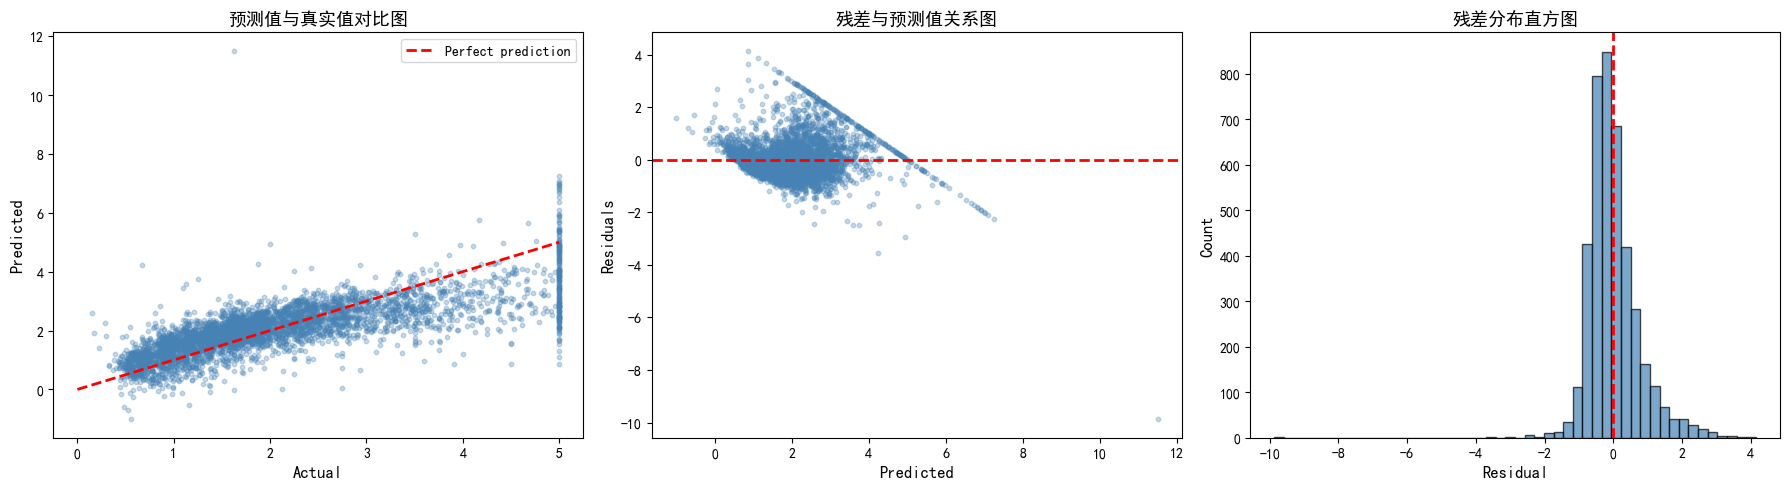

残差均值: 0.0035
残差标准差: 0.7456
残差偏度: 0.5459


In [19]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 图1：预测值 vs 真实值
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual', fontsize=12)
axes[0].set_ylabel('Predicted', fontsize=12)
axes[0].set_title('预测值与真实值对比图', fontsize=13)
axes[0].legend()

# 图2：残差 vs 预测值
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color='steelblue')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('残差与预测值关系图', fontsize=13)

# 图3：残差分布
axes[2].hist(residuals, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Residual', fontsize=12)
axes[2].set_ylabel('Count', fontsize=12)
axes[2].set_title('残差分布直方图', fontsize=13)

plt.tight_layout()
plt.show()

# 残差统计
print(f"残差均值: {residuals.mean():.4f}")
print(f"残差标准差: {residuals.std():.4f}")
print(f"残差偏度: {pd.Series(residuals).skew():.4f}")

## 预测值与真实值对比图

理想情况下，所有点都应落在红色对角线上

图示数据点大致沿对角线分布，模型整体具备预测能力，但存在明显的系统性偏差：
  1. 真实值较高时，预测值普遍偏低（点落在红线下方），说明 **模型倾向于低估高价房产**
  2. 右侧出现的<span id = "tag0402"> **垂直聚集现象** </span>（大量真实值为 5.0 的样本），正是前面提到的[数据截断操作](#tag0401)产生的效应


## 残差值与预测值关系图

如果模型没有系统性问题，散点应该均匀、随机地分布在红色零线两侧

但我们看到：
1. 随着预测值增大，残差的发散程度也在变大，呈现出漏斗的形状
2. 这说明 **模型预测高房价时非常不稳定**，误差忽大忽小。

## 残差分布直方图

理想的残差应近似正态分布、均值为 0。

虽然图中残差的峰值确实集中在零附近，但整体呈现右偏且带有长尾。
- 印证了模型对部分高房价样本预测不准、严重低估的问题。

# 4. 交叉验证

## K-Fold
### 单指标 RMSE

In [20]:
from sklearn.model_selection import cross_val_score

# 注意：cross_val_score 会在内部完成 fit 和 predict，不需要手动划分
scores = cross_val_score(
    LinearRegression(), X_scaled, y,
    cv=5,                              # 5 折交叉验证
    scoring='neg_mean_squared_error'   # sklearn 约定：scoring 越大越好，MSE 前面加负号
)

# 将负 MSE 转换回 RMSE
rmse_scores = np.sqrt(-scores)

print("每折 RMSE:")
for i, score in enumerate(rmse_scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"\n平均 RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

每折 RMSE:
  Fold 1: 0.6963
  Fold 2: 0.7890
  Fold 3: 0.8039
  Fold 4: 0.7370
  Fold 5: 0.7033

平均 RMSE: 0.7459 ± 0.0437


In [ ]:
print(f"\n标准差 {rmse_scores.std() :.4f} 相对于 平均值 {rmse_scores.mean() :.4f} 约 {rmse_scores.std() / rmse_scores.mean() * 100 :.2f}%")

标准差 0.0437 相对于 平均值 0.7459 约 5.86%


这说明线性回归模型在不同数据划分下表现非常稳定

这是线性模型的一个典型优势：方差低、稳定性好。

### 多指标 RMSE + MAE + R2

In [ ]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    LinearRegression(), X_scaled, y,
    cv=5,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    return_train_score=True  # 同时返回训练集上的得分（用于诊断过拟合）
)

print(f"{'指标':<12} {'训练集':>12} {'测试集':>12} {'差距':>10}")
print("-" * 48)
for metric in ['rmse', 'mae', 'r2']:
    train_key = f'train_{metric}'
    test_key = f'test_{metric}'
    
    if metric == 'r2':
        train_mean = cv_results[train_key].mean()
        test_mean = cv_results[test_key].mean()
    else:
        train_mean = -cv_results[train_key].mean()  # 去掉负号
        test_mean = -cv_results[test_key].mean()
    
    gap = abs(train_mean - test_mean)
    print(f"{metric.upper():<12} {train_mean:>16.4f} {test_mean:>16.4f} {gap:>14.4f}")

指标                    训练集          测试集         差距
------------------------------------------------
RMSE                   0.7218           0.7459         0.0241
MAE                    0.5297           0.5475         0.0178
R2                     0.6071           0.5530         0.0541


1. 训练集和测试集的指标非常接近
  - 这种模式说明模型没有过拟合
  - 过拟合的特征是训练集上表现很好、测试集上表现很差
2. 训练集上的表现本身也不算出色
  - R² 只有 0.61
  - 模型可能还没有充分挖掘数据中的信息，即欠拟合